# Benchmark de descarga Rigol MSO2102A

Este notebook compara la implementacion legacy de `oscrigol.getchannels` contra la implementacion optimizada `getchannelsFast`.

Setup experimental usado para estas pruebas:

- Canal activo: **CH1**
- Senal de prueba: generador conectado a CH1
- Trigger: **CH1**, flanco positivo, nivel **100 mV**
- Escala vertical inicial: **50 mV/div**
- Escala horizontal: **10 us/div**
- Profundidad de memoria inicial: **70000 puntos**

El objetivo es medir cuanto tarda cada adquisicion completa y separar dos mejoras posibles:

1. Cambiar sincronizacion por sleeps fijos a `:SINGle` + polling de estado de trigger.
2. Comparar transporte VISA `INSTR` contra raw socket `SOCKET` en puerto 5555.

## 1. Seguridad antes de tocar el equipo

Por defecto, este notebook no abre comunicacion con el osciloscopio. Cambiar `RUN_HARDWARE` a `True` solo cuando el Rigol y el generador esten listos.

Si el raw socket no responde, probar primero con `TRANSPORT = "instr"`. El modo socket requiere que el Rigol acepte conexiones en el puerto 5555.

In [5]:
RUN_HARDWARE = True  # Cambiar a True para medir con el Rigol real

IP_ADDRESS = "192.168.2.2"
TRANSPORT = "socket"  # "instr" o "socket"
VISA_BACKEND = "@py"  # usar "default" para NI-VISA si corresponde

CHANNELS = (1,)
MDEPTH = 70000
ITERATIONS = 32

TRIGGER_SOURCE = "CHAN1"
TRIGGER_LEVEL = 0.1  # 100 mV
TRIGGER_COUPLING = "AC"
TRIGGER_SLOPE = "POS"

VERTICAL_SCALE = 0.05  # 50 mV/div
HORIZONTAL_SCALE = 10e-6  # 10 us/div

POLL_INTERVAL = 0.005
TRIGGER_TIMEOUT = 5.0
WAVEFORM_DELAY = 0.01
ARM_DELAY = 0.05  # espera tras :SINGle antes de consultar :TRIGger:STATus?
MAX_RETRIES_FAST = 1  # reintentos si fast devuelve lectura vacia o rechazada
MIN_VPP_FAST = None  # ejemplo: 0.05 para rechazar capturas con menos de 50 mVpp

## 2. Imports y carga de la clase

Como la carpeta `rigol-MSO2102A` tiene un guion en el nombre, cargamos `oscrigol.py` por path usando `importlib`.

In [6]:
import csv
import importlib.util
import statistics
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd()
if HERE.name != "rigol-MSO2102A":
    HERE = Path("oscilloscopes/rigol-MSO2102A").resolve()

OSCRIGOL_PATH = HERE / "oscrigol.py"
spec = importlib.util.spec_from_file_location("oscrigol_module", OSCRIGOL_PATH)
oscrigol_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(oscrigol_module)
oscrigol = oscrigol_module.oscrigol

OSCRIGOL_PATH

PosixPath('/home/federico/git/GLOmAe-scripts-2-control-instruments/oscilloscopes/rigol-MSO2102A/oscrigol.py')

## 3. Funciones auxiliares

`build_scope` crea el objeto con `INSTR` o `SOCKET`. `prepare_scope` configura trigger, canal, escalas, adquisicion normal y profundidad de memoria.

Nota: para comparar de forma justa, se prepara el osciloscopio antes de cada bloque de pruebas.

In [7]:
def build_scope(transport="instr", download_mode="legacy"):
    scope = oscrigol(
        ip_address=IP_ADDRESS,
        use_socket=(transport == "socket"),
        socket_port=5555,
        visa_backend=None if VISA_BACKEND == "default" else VISA_BACKEND,
    )
    scope.config(
        channels=CHANNELS,
        chanBand=("20M",),
        chanCoup=("AC",),
        chanInv=("OFF",),
        chanImp=("OMEG",),
        trigSource=TRIGGER_SOURCE,
        trigCoup=TRIGGER_COUPLING,
        trigLevel=TRIGGER_LEVEL,
        trigSlope=TRIGGER_SLOPE,
        acquisition=1,
        mdepth=MDEPTH,
        download_mode=download_mode,
    )
    return scope


def prepare_scope(scope):
    scope.initComm()
    print(scope.getID().strip())
    scope.setEdgeTrigger(TRIGGER_SOURCE, TRIGGER_SLOPE, TRIGGER_COUPLING, TRIGGER_LEVEL)
    scope.setChannel(1, "20M", "AC", "OFF", "OMEG")
    scope.setVertScale(1, VERTICAL_SCALE)
    scope.setHorScale(HORIZONTAL_SCALE)
    scope.run()
    scope.setSampAcquisition()
    check = scope.setandcheckmdepth(MDEPTH)
    if check:
        scope.closeComm()
        raise RuntimeError("El Rigol rechazo la profundidad de memoria solicitada")
    return scope


def close_scope(scope):
    try:
        scope.closeComm()
    except Exception as exc:
        print(f"No se pudo cerrar la comunicacion limpiamente: {exc}")

## 4. Prueba rapida de conexion

Esta celda solo abre comunicacion, consulta `*IDN?` y cierra. Conviene correrla antes del benchmark.

In [8]:
if RUN_HARDWARE:
    scope = build_scope(TRANSPORT)
    try:
        scope.initComm()
        print(scope.getID())
    finally:
        close_scope(scope)
else:
    print("RUN_HARDWARE = False; no se abre comunicacion con el Rigol.")

RIGOL TECHNOLOGIES,MSO2102A,DS2F214100395,00.03.06


## 5. Una adquisicion legacy y una fast

Esta prueba sirve para ver que ambas rutas devuelven datos razonables antes de hacer muchas iteraciones.

En el modo fast, el osciloscopio queda esperando un disparo unico. Si no llega trigger en `TRIGGER_TIMEOUT`, la celda falla con timeout.

In [9]:
single_results = {}

if RUN_HARDWARE:
    for mode, method_name in [("legacy", "getchannels"), ("fast", "getchannelsFast")]:
        scope = build_scope(TRANSPORT, download_mode=mode)
        try:
            prepare_scope(scope)
            method = getattr(scope, method_name)
            t0 = time.perf_counter()
            if method_name == "getchannelsFast":
                values, vmax = method(
                    CHANNELS,
                    MDEPTH,
                    poll_interval=POLL_INTERVAL,
                    trigger_timeout=TRIGGER_TIMEOUT,
                    waveform_delay=WAVEFORM_DELAY,
                    arm_delay=ARM_DELAY,
                    max_retries=MAX_RETRIES_FAST,
                    min_vpp=MIN_VPP_FAST,
                )
            else:
                values, vmax = method(CHANNELS, MDEPTH)
            elapsed = time.perf_counter() - t0
            single_results[method_name] = (np.asarray(values), vmax, elapsed)
            print(f"{method_name}: {elapsed:.3f} s, samples={np.asarray(values).shape[-1]}, vmax_ch2={vmax:.4g}")
        finally:
            close_scope(scope)
else:
    print("RUN_HARDWARE = False; saltando adquisicion real.")

RIGOL TECHNOLOGIES,MSO2102A,DS2F214100395,00.03.06
getchannels: 1.416 s, samples=70000, vmax_ch2=0.02
RIGOL TECHNOLOGIES,MSO2102A,DS2F214100395,00.03.06
getchannelsFast: 1.087 s, samples=70000, vmax_ch2=0.02


## 6. Visualizacion de la adquisicion de prueba

Grafica las senales capturadas en la celda anterior. La escala temporal se calcula con una aproximacion usando la ventana horizontal configurada.

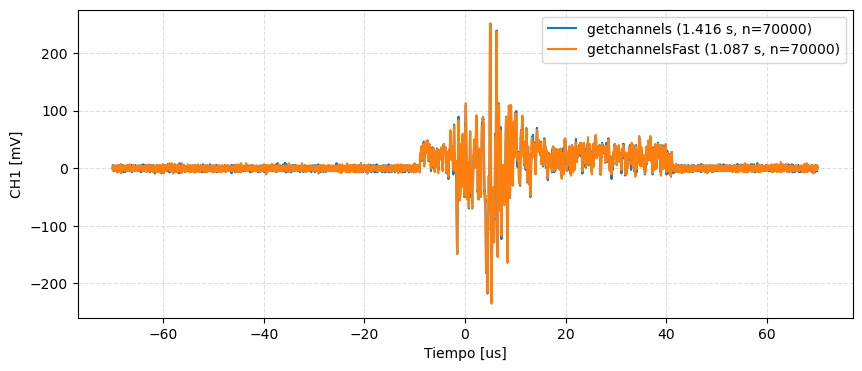

In [10]:
if single_results:
    plt.figure(figsize=(10, 4))
    for method_name, (values, vmax, elapsed) in single_results.items():
        y = values.reshape(-1)
        if y.size == 0:
            print(f"{method_name}: lectura vacia, no se grafica")
            continue
        t = np.linspace(-7 * HORIZONTAL_SCALE, 7 * HORIZONTAL_SCALE, y.size)
        plt.plot(t * 1e6, y * 1e3, label=f"{method_name} ({elapsed:.3f} s, n={y.size})")
    plt.xlabel("Tiempo [us]")
    plt.ylabel("CH1 [mV]")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.show()
else:
    print("No hay resultados para graficar todavia.")

## 7. Benchmark legacy vs fast

Corre `ITERATIONS` adquisiciones con cada metodo. Cada fila mide una llamada completa a `getchannels` o `getchannelsFast`.

In [11]:
def run_benchmark(transport="instr", iterations=10, keep_waveforms=True):
    rows = []
    waveforms = []
    for mode, method_name in [("legacy", "getchannels"), ("fast", "getchannelsFast")]:
        scope = build_scope(transport, download_mode=mode)
        try:
            prepare_scope(scope)
            method = getattr(scope, method_name)
            for idx in range(iterations):
                t0 = time.perf_counter()
                if method_name == "getchannelsFast":
                    values, vmax = method(
                        CHANNELS,
                        MDEPTH,
                        poll_interval=POLL_INTERVAL,
                        trigger_timeout=TRIGGER_TIMEOUT,
                        waveform_delay=WAVEFORM_DELAY,
                        arm_delay=ARM_DELAY,
                        max_retries=MAX_RETRIES_FAST,
                        min_vpp=MIN_VPP_FAST,
                    )
                else:
                    values, vmax = method(CHANNELS, MDEPTH)
                elapsed = time.perf_counter() - t0
                rows.append({
                    "transport": transport,
                    "method": method_name,
                    "iteration": idx + 1,
                    "elapsed_s": elapsed,
                    "samples": int(np.asarray(values).shape[-1]),
                    "vmax_ch2": float(vmax),
                })
                if keep_waveforms:
                    waveforms.append({
                        "transport": transport,
                        "method": method_name,
                        "iteration": idx + 1,
                        "elapsed_s": elapsed,
                        "values": np.asarray(values).reshape(-1).copy(),
                    })
                print(f"{transport} {method_name} {idx + 1}/{iterations}: {elapsed:.3f} s")
        finally:
            close_scope(scope)
    return rows, waveforms


if RUN_HARDWARE:
    benchmark_rows, benchmark_waveforms = run_benchmark(TRANSPORT, ITERATIONS)
else:
    benchmark_rows = []
    benchmark_waveforms = []
    print("RUN_HARDWARE = False; saltando benchmark real.")

benchmark_rows[:3]

RIGOL TECHNOLOGIES,MSO2102A,DS2F214100395,00.03.06
socket getchannels 1/32: 1.390 s
socket getchannels 2/32: 1.341 s
socket getchannels 3/32: 1.525 s
socket getchannels 4/32: 1.346 s
socket getchannels 5/32: 1.519 s
socket getchannels 6/32: 1.341 s
socket getchannels 7/32: 1.533 s
socket getchannels 8/32: 1.341 s
socket getchannels 9/32: 1.531 s
socket getchannels 10/32: 1.341 s
socket getchannels 11/32: 1.528 s
socket getchannels 12/32: 1.342 s
socket getchannels 13/32: 1.529 s
socket getchannels 14/32: 1.343 s
socket getchannels 15/32: 1.536 s
socket getchannels 16/32: 1.343 s
socket getchannels 17/32: 1.467 s
socket getchannels 18/32: 1.350 s
socket getchannels 19/32: 1.342 s
socket getchannels 20/32: 1.521 s
socket getchannels 21/32: 1.341 s
socket getchannels 22/32: 1.527 s
socket getchannels 23/32: 1.342 s
socket getchannels 24/32: 1.523 s
socket getchannels 25/32: 1.341 s
socket getchannels 26/32: 1.529 s
socket getchannels 27/32: 1.342 s
socket getchannels 28/32: 1.512 s
socket

[{'transport': 'socket',
  'method': 'getchannels',
  'iteration': 1,
  'elapsed_s': 1.390125818001252,
  'samples': 70000,
  'vmax_ch2': 0.02},
 {'transport': 'socket',
  'method': 'getchannels',
  'iteration': 2,
  'elapsed_s': 1.3407689899995603,
  'samples': 70000,
  'vmax_ch2': 0.02},
 {'transport': 'socket',
  'method': 'getchannels',
  'iteration': 3,
  'elapsed_s': 1.5246669459993427,
  'samples': 70000,
  'vmax_ch2': 0.02}]

## 8. Superposicion de mediciones por metodo

Esta celda superpone todas las formas de onda medidas por cada metodo en dos subplots. Sirve para verificar visualmente que `getchannelsFast` no este devolviendo otro evento, ruido, una ventana temporal distinta o una lectura corrupta.

La linea negra es el promedio de las iteraciones de cada metodo.

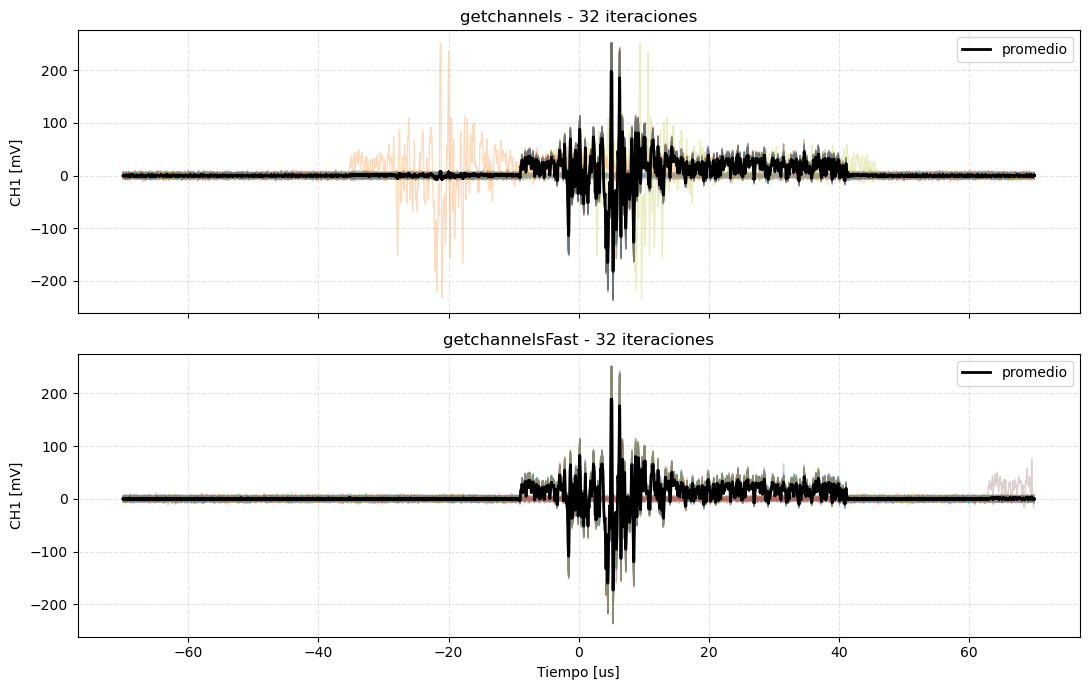

In [12]:
def plot_waveform_overlay(waveforms):
    methods = ["getchannels", "getchannelsFast"]
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, sharey=True)

    for ax, method in zip(axes, methods):
        method_waveforms = [row for row in waveforms if row["method"] == method]
        if not method_waveforms:
            ax.set_title(f"{method}: sin datos")
            ax.grid(True, linestyle="--", alpha=0.35)
            continue

        traces = []
        for row in method_waveforms:
            y = row["values"]
            if y.size == 0:
                print(f"{method} iter {row['iteration']}: lectura vacia")
                continue
            t = np.linspace(-7 * HORIZONTAL_SCALE, 7 * HORIZONTAL_SCALE, y.size)
            ax.plot(t * 1e6, y * 1e3, alpha=0.28, linewidth=0.9)
            traces.append(y)

        if traces:
            min_len = min(trace.size for trace in traces)
            stack = np.vstack([trace[:min_len] for trace in traces])
            t_mean = np.linspace(-7 * HORIZONTAL_SCALE, 7 * HORIZONTAL_SCALE, min_len)
            ax.plot(t_mean * 1e6, stack.mean(axis=0) * 1e3, color="black", linewidth=2.0, label="promedio")
            ax.legend(loc="best")

        ax.set_title(f"{method} - {len(method_waveforms)} iteraciones")
        ax.set_ylabel("CH1 [mV]")
        ax.grid(True, linestyle="--", alpha=0.35)

    axes[-1].set_xlabel("Tiempo [us]")
    fig.tight_layout()
    plt.show()


if benchmark_waveforms:
    plot_waveform_overlay(benchmark_waveforms)
else:
    print("No hay formas de onda guardadas. Ejecutar primero la celda del benchmark con keep_waveforms=True.")

## 9. Conteo de senales validas vs ruido

Esta celda clasifica cada captura usando un umbral de tension pico a pico. La idea es detectar rapidamente cuantas iteraciones parecen contener la senal del generador y cuantas parecen ser solo ruido/base.

Ajustar `SIGNAL_VPP_THRESHOLD` segun la amplitud esperada. Por ejemplo, `0.05` equivale a 50 mVpp.

In [16]:
SIGNAL_VPP_THRESHOLD = 0.05  # [V] ajustar segun la senal real del generador


def classify_signal_noise(waveforms, vpp_threshold):
    rows = []
    for row in waveforms:
        y = np.asarray(row["values"]).reshape(-1)
        if y.size == 0:
            vpp = 0.0
            rms = 0.0
            std = 0.0
            label = "vacia"
        else:
            vpp = float(np.ptp(y))
            rms = float(np.sqrt(np.mean(y**2)))
            std = float(np.std(y))
            label = "senal" if vpp >= vpp_threshold else "ruido"

        rows.append({
            "transport": row["transport"],
            "method": row["method"],
            "iteration": row["iteration"],
            "elapsed_s": row["elapsed_s"],
            "vpp_v": vpp,
            "rms_v": rms,
            "std_v": std,
            "label": label,
        })
    return rows


def print_signal_noise_summary(classified_rows):
    groups = {}
    for row in classified_rows:
        key = (row["transport"], row["method"])
        groups.setdefault(key, []).append(row)

    for (transport, method), rows in groups.items():
        n_signal = sum(row["label"] == "senal" for row in rows)
        n_noise = sum(row["label"] == "ruido" for row in rows)
        n_empty = sum(row["label"] == "vacia" for row in rows)
        vpps = [row["vpp_v"] for row in rows]
        print(
            f"{transport} {method}: "
            f"senal={n_signal}, ruido={n_noise}, vacia={n_empty}, total={len(rows)}, "
            f"Vpp mediana={statistics.median(vpps)*1e3:.1f} mV, "
            f"Vpp min={min(vpps)*1e3:.1f} mV, Vpp max={max(vpps)*1e3:.1f} mV"
        )


if benchmark_waveforms:
    classified_rows = classify_signal_noise(benchmark_waveforms, SIGNAL_VPP_THRESHOLD)
    print_signal_noise_summary(classified_rows)
    classified_rows[:5]
else:
    classified_rows = []
    print("No hay formas de onda guardadas. Ejecutar primero la celda del benchmark.")

socket getchannels: senal=27, ruido=5, vacia=0, total=32, Vpp mediana=484.3 mV, Vpp min=17.7 mV, Vpp max=488.2 mV
socket getchannelsFast: senal=25, ruido=7, vacia=0, total=32, Vpp mediana=483.3 mV, Vpp min=17.7 mV, Vpp max=488.2 mV


## 10. Evolucion temporal del benchmark

Arriba se grafica el tiempo de cada iteracion. Abajo se grafica el tiempo acumulado por metodo; el ultimo punto es el tiempo total empleado por esas iteraciones.

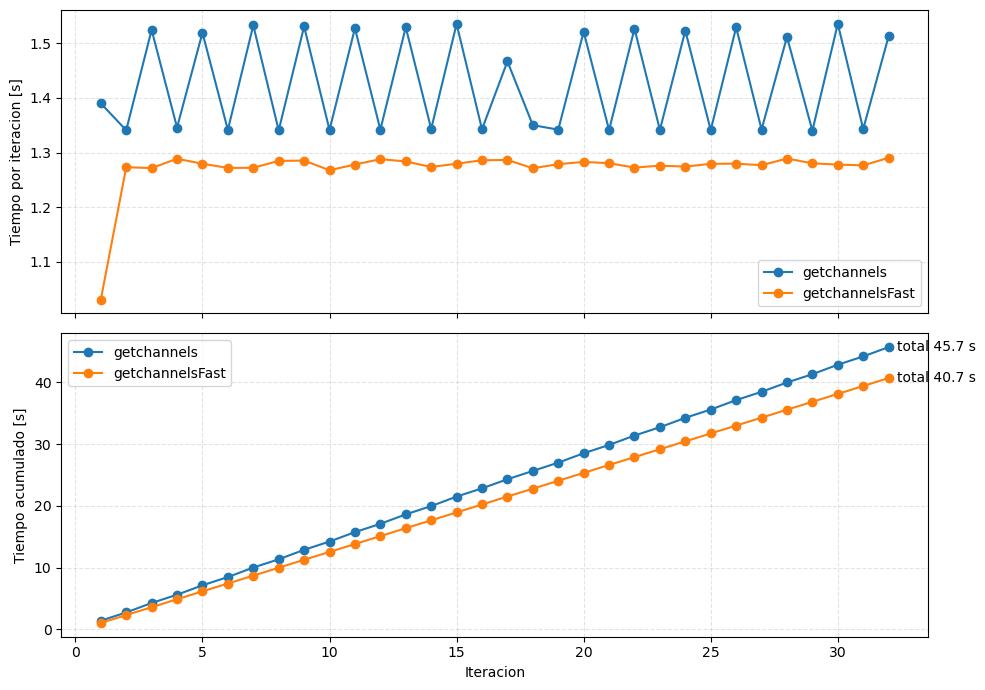

In [17]:
def plot_timing_evolution(rows):
    methods = ["getchannels", "getchannelsFast"]
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    for method in methods:
        method_rows = [row for row in rows if row["method"] == method]
        if not method_rows:
            continue
        method_rows = sorted(method_rows, key=lambda row: row["iteration"])
        iterations = np.array([row["iteration"] for row in method_rows])
        elapsed = np.array([row["elapsed_s"] for row in method_rows])
        cumulative = np.cumsum(elapsed)

        axes[0].plot(iterations, elapsed, marker="o", label=f"{method}")
        axes[1].plot(iterations, cumulative, marker="o", label=f"{method}")
        axes[1].annotate(
            f"total {cumulative[-1]:.1f} s",
            xy=(iterations[-1], cumulative[-1]),
            xytext=(6, 0),
            textcoords="offset points",
            va="center",
        )

    axes[0].set_ylabel("Tiempo por iteracion [s]")
    axes[0].grid(True, linestyle="--", alpha=0.35)
    axes[0].legend(loc="best")

    axes[1].set_xlabel("Iteracion")
    axes[1].set_ylabel("Tiempo acumulado [s]")
    axes[1].grid(True, linestyle="--", alpha=0.35)
    axes[1].legend(loc="best")

    fig.tight_layout()
    plt.show()


if benchmark_rows:
    plot_timing_evolution(benchmark_rows)
else:
    print("No hay datos temporales. Ejecutar primero la celda del benchmark.")

## 11. Resumen y guardado

La mediana suele ser mas representativa que el promedio si hay algun trigger o paquete de red atipico.

In [18]:
def summarize_rows(rows):
    groups = {}
    for row in rows:
        key = (row["transport"], row["method"])
        groups.setdefault(key, []).append(row["elapsed_s"])

    summary = []
    for (transport, method), values in groups.items():
        summary.append({
            "transport": transport,
            "method": method,
            "count": len(values),
            "mean_s": statistics.mean(values),
            "median_s": statistics.median(values),
            "min_s": min(values),
            "max_s": max(values),
            "std_s": statistics.stdev(values) if len(values) > 1 else 0.0,
        })
    return summary


if benchmark_rows:
    summary = summarize_rows(benchmark_rows)
    for row in summary:
        print(
            f"{row['transport']} {row['method']}: "
            f"n={row['count']} median={row['median_s']:.3f}s "
            f"mean={row['mean_s']:.3f}s min={row['min_s']:.3f}s max={row['max_s']:.3f}s"
        )

    output_path = HERE / f"benchmark_oscrigol_{TRANSPORT}_ch1.csv"
    with open(output_path, "w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=benchmark_rows[0].keys())
        writer.writeheader()
        writer.writerows(benchmark_rows)
    print(f"Resultados guardados en: {output_path}")
else:
    print("No hay datos de benchmark para resumir.")

socket getchannels: n=32 median=1.370s mean=1.428s min=1.340s max=1.536s
socket getchannelsFast: n=32 median=1.279s mean=1.271s min=1.030s max=1.290s
Resultados guardados en: /home/federico/git/GLOmAe-scripts-2-control-instruments/oscilloscopes/rigol-MSO2102A/benchmark_oscrigol_socket_ch1.csv


## 12. Comparar INSTR vs SOCKET

Cuando la prueba con `TRANSPORT = "instr"` funcione, repetir con `TRANSPORT = "socket"`. Tambien se puede correr la celda siguiente para medir ambos transportes en una sola tanda.

Usar esta celda solo si el Rigol responde bien por ambos caminos.

In [19]:
RUN_BOTH_TRANSPORTS = True

if RUN_HARDWARE and RUN_BOTH_TRANSPORTS:
    rows_instr, _ = run_benchmark("instr", ITERATIONS, keep_waveforms=False)
    rows_socket, _ = run_benchmark("socket", ITERATIONS, keep_waveforms=False)
    rows_both = rows_instr + rows_socket
    for row in summarize_rows(rows_both):
        print(
            f"{row['transport']} {row['method']}: "
            f"n={row['count']} median={row['median_s']:.3f}s "
            f"mean={row['mean_s']:.3f}s min={row['min_s']:.3f}s max={row['max_s']:.3f}s"
        )
else:
    print("Celda desactivada. Cambiar RUN_BOTH_TRANSPORTS a True para comparar ambos transportes.")

RIGOL TECHNOLOGIES,MSO2102A,DS2F214100395,00.03.06
instr getchannels 1/32: 3.462 s
instr getchannels 2/32: 3.560 s
instr getchannels 3/32: 3.527 s
instr getchannels 4/32: 3.414 s
instr getchannels 5/32: 3.435 s
instr getchannels 6/32: 3.566 s
instr getchannels 7/32: 3.437 s
instr getchannels 8/32: 3.526 s
instr getchannels 9/32: 3.419 s
instr getchannels 10/32: 3.404 s
instr getchannels 11/32: 3.441 s
instr getchannels 12/32: 3.548 s
instr getchannels 13/32: 3.424 s
instr getchannels 14/32: 3.573 s
instr getchannels 15/32: 3.402 s
instr getchannels 16/32: 3.414 s
instr getchannels 17/32: 3.421 s
instr getchannels 18/32: 3.443 s
instr getchannels 19/32: 3.465 s
instr getchannels 20/32: 3.425 s
instr getchannels 21/32: 3.466 s
instr getchannels 22/32: 3.549 s
instr getchannels 23/32: 3.431 s
instr getchannels 24/32: 3.430 s
instr getchannels 25/32: 3.431 s
instr getchannels 26/32: 3.534 s
instr getchannels 27/32: 3.577 s
instr getchannels 28/32: 3.557 s
instr getchannels 29/32: 3.436 s
i

## Interpretacion esperada

- Si `getchannelsFast` mejora mucho frente a `getchannels`, el cuello principal eran las esperas fijas y la sincronizacion `RUN/sleep/STOP`.
- Si `socket` mejora frente a `instr`, hay overhead importante del transporte VXI-11/INSTR.
- Si ambas rutas siguen lentas, conviene instrumentar tiempos internos: polling de trigger, configuracion de waveform, transferencia binaria y conversion `numpy`.

Para el experimento largo de 1024 mediciones, una mejora de 1 segundo por medicion equivale a unos 17 minutos menos de tiempo total.